# Transformer

Dataset de señales EMG para clasificación de 4 gestos de la mano:
- 0 --> Piedra
- 1 --> Tijera
- 2 --> Papel
- 3 --> Ok

64 columnas 8 canales EMG x 8 intentes de tiempo por ventana.

## Imports y config

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import warnings

warnings.filterwarnings('ignore')

c:\Users\Rocío\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.sparse import csr_matrix, issparse


In [2]:
random_state = 42
np.random.seed(random_state)

## Carga dataset

In [3]:
df_0 = pd.read_csv("data/0.csv", header=None)
df_1 = pd.read_csv("data/1.csv", header=None)
df_2 = pd.read_csv("data/2.csv", header=None)
df_3 = pd.read_csv("data/3.csv", header=None)

dfs_por_clase = {0: df_0, 1: df_1, 2: df_2, 3: df_3}

df = pd.concat([df_0, df_1, df_2, df_3], ignore_index=True)

# Se cambia nombre de las columnas
sensor_cols = [f'S{i}' for i in range(64)]
df.columns = sensor_cols + ['label']
for k in dfs_por_clase:
    dfs_por_clase[k].columns = sensor_cols + ['label']

X = df[sensor_cols]
y = df['label']

## Entrenamiento y prueba

In [4]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

# Escalar datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Formato de X_train antes del Transformer: {X_train.shape}")

Formato de X_train antes del Transformer: (9342, 64)


## Transformer

In [5]:
# Redimensionar datos
X_train_3d = X_train.reshape(-1, 8, 8) # (N, 8 tiempos, 8 canales)
X_test_3d = X_test.reshape(-1, 8, 8)

# NumPy -> PyTorch
X_train_tensor = torch.tensor(X_train_3d, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_3d, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Ahorra todo el coste computacional de preprocesar TD/FD, ya que aprende las características óptimas directamente de la secuencia en bruto.

In [6]:
# Transformer
class EMGTransformer(nn.Module):
    def __init__(self, input_size=8, d_model=32, nhead=4, num_layers=2, num_classes=4):
        super(EMGTransformer, self).__init__()
        
        # 8 canales -> Tamaño Transformer
        self.embedding = nn.Linear(input_size, d_model)
        
        # Positional encoding -> longitud 8
        self.positional_encoding = nn.Parameter(torch.randn(1, 8, d_model))
        
        # Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Salida
        self.fc = nn.Linear(d_model, num_classes)
        
    def forward(self, x):
        # (Batch, 8, 8) -> (Batch, 8, 32)
        x = self.embedding(x)
        x = x + self.positional_encoding # + tiempo
        
        x = self.transformer_encoder(x)
        
        # Media tiempo -> (Batch, 32)
        x = x.mean(dim=1)
        # (Batch, 32) -> (Batch, 4)
        x = self.fc(x)
        return x

In [12]:
model = EMGTransformer()

# CrossEntropy para clasificar y el optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 25
start_train = time.time()
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad() # Limpiar gradientes
        outputs = model(batch_X) # Prediccion
        loss = criterion(outputs, batch_y) # Error
        loss.backward() # Backpropagation
        optimizer.step() # Actualizar pesos
        total_loss += loss.item()
        
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss promedio: {total_loss/len(train_loader):.4f}")

end_train = time.time() 
tiempo_training_total = end_train - start_train

# Evaluacion
model.eval()
correct = 0
total = 0

with torch.no_grad(): # Desactivamos gradientes para evaluar más rápido
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy final del Transformer en Test: {accuracy:.2f}%")

Epoch 5/25 | Loss promedio: 0.0995
Epoch 10/25 | Loss promedio: 0.0608
Epoch 15/25 | Loss promedio: 0.0446
Epoch 20/25 | Loss promedio: 0.0321
Epoch 25/25 | Loss promedio: 0.0340
Accuracy final del Transformer en Test: 96.88%


### Añadir ruido

In [8]:
# Desviación estandar de X_test
std_test = np.std(X_test_3d)

# Ruido uniforme
noise = np.random.uniform(-0.3 * std_test, 0.3 * std_test, X_test_3d.shape)

X_test_noise_3d = X_test_3d + noise

# DataLoader para el ruido
X_test_noise_tensor = torch.tensor(X_test_noise_3d, dtype=torch.float32)
test_noise_dataset = TensorDataset(X_test_noise_tensor, y_test_tensor) # y_test_tensor ya lo tenías
test_noise_loader = DataLoader(test_noise_dataset, batch_size=32, shuffle=False)

## Latencia

In [9]:
def accuracy_and_latency_transformer(modelo, loader):
    modelo.eval()
    correct = 0
    total = 0
    latencias = []
    
    with torch.no_grad():
        # Hacemos 5 pasadas para medir el tiempo medio, igual que tus compañeros
        for i in range(5): 
            start = time.time()
            
            for batch_X, batch_y in loader:
                outputs = modelo(batch_X)
                _, predicted = torch.max(outputs.data, 1)
                
                # Solo contamos los aciertos en la última pasada para no duplicarlos
                if i == 4:
                    total += batch_y.size(0)
                    correct += (predicted == batch_y).sum().item()
                    
            end = time.time()
            latencias.append(end - start)
            
    elapsed = np.mean(latencias)
    acc = correct / total  # Lo dejamos en formato 0.97... en vez de 97% para la tabla
    return acc, elapsed

## Matriz de confusión

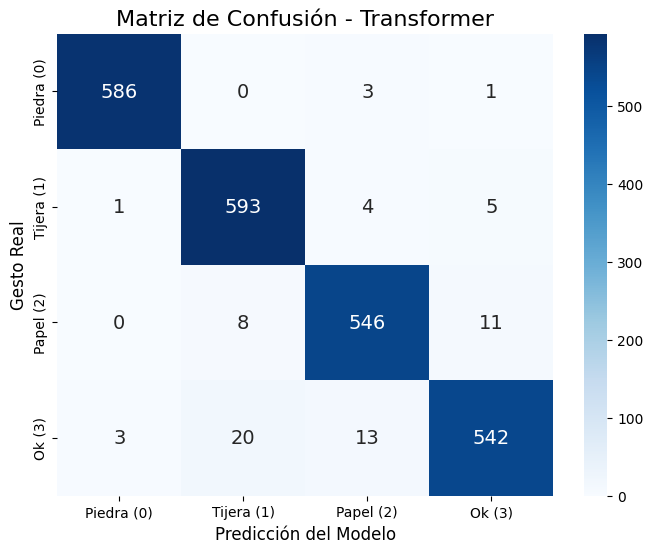

In [10]:
# Predicciones test
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(batch_y.numpy())

# Matriz
cm = confusion_matrix(all_labels, all_preds)
clases = ['Piedra (0)', 'Tijera (1)', 'Papel (2)', 'Ok (3)']

# Grafica
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clases, yticklabels=clases, 
            annot_kws={"size": 14})

plt.title('Matriz de Confusión - Transformer', fontsize=16)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Gesto Real', fontsize=12)
plt.show()

In [15]:
# Evaluar SIN ruido
acc_trans, time_trans = accuracy_and_latency_transformer(model, test_loader)

# Evaluar CON ruido
acc_trans_n, time_trans_n = accuracy_and_latency_transformer(model, test_noise_loader)

# Latencia media
lat_trans = (time_trans + time_trans_n) / 2

print("Resultados del transformer")
print(f"Accuracy sin ruido: {acc_trans:.4f}")
print(f"Accuracy con ruido: {acc_trans_n:.4f}")
print(f"Latencia media (s): {lat_trans:.4f}")
print(f"Tiempo de training: {tiempo_training_total:.2f} s")

Resultados del transformer
Accuracy sin ruido: 0.9688
Accuracy con ruido: 0.9045
Latencia media (s): 0.2152
Tiempo de training: 234.06 s
